# Supervised learning tasks

# Classification

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2970
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})
Shape of train set: (9000, 2)
Shape of validation set: (1000, 2)
Shape of test set: (2970, 2)

label 0: 'non-hate'
label 1: 'hate'


Text length statistics (train set):
             count        mean        std   min   25%    50%    75%    max
label_name                                                                
hate        3783.0  130.119218  67.572722  10.0  79.0  116.0  173.0  292.0
non-hate    5217.0  117.554725  66.435593   0.0  68.0  105.0  140.0  303.0


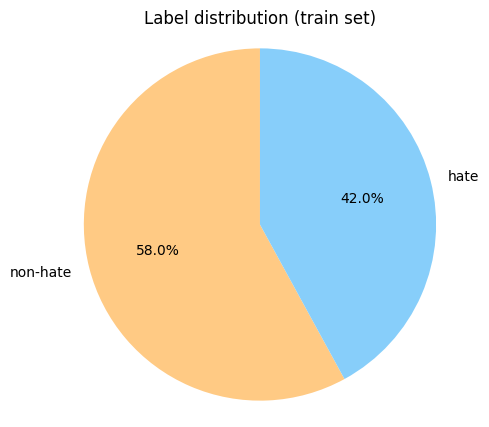

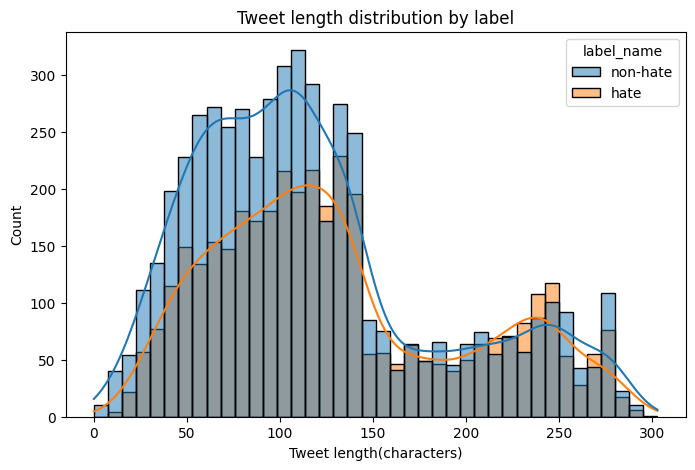

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset('cardiffnlp/tweet_eval','hate')
print(dataset)

#description of the task and give some hypotheses:

# Goal: to train model to find hater's tweets. For example, this is useful for users, they can block haters, filter content and etc
# Task described: to teach model to split tweets on hate or non-hate ones.
# Hypothesis:
# 1)hate tweets might have more capital letters(people shout in hate)
# 2)hate tweets may use negative sentiment words more often (swear words, curse words, vulgar words)
# 3)difficult to detect sarcasm/irony, model can make mistakes with it

train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

#show the data statistics, shape and etc. :
print('Shape of train set:', train_df.shape)
print('Shape of validation set:', val_df.shape)
print('Shape of test set:', test_df.shape)

train_df['text_length'] = train_df['text'].apply(len)

print(f'''\nlabel 0: 'non-hate'
label 1: 'hate'
''')

label_map = {0: "non-hate", 1: "hate"}

train_df['label_name'] = train_df['label'].map(label_map)
train_df['text_length'] = train_df['text'].apply(len)

print("\nText length statistics (train set):")
print(train_df.groupby('label_name')['text_length'].describe())


# plotting for better representation
label_counts = train_df['label_name'].value_counts()

plt.figure(figsize=(5,5))
colors = ['#FFCA84','#87CEFA']
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Label distribution (train set)")
plt.axis('equal')
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=train_df,x='text_length',hue='label_name',bins=40,kde=True)
plt.title("Tweet length distribution by label")
plt.xlabel("Tweet length(characters)")
plt.ylabel("Count")
plt.show()

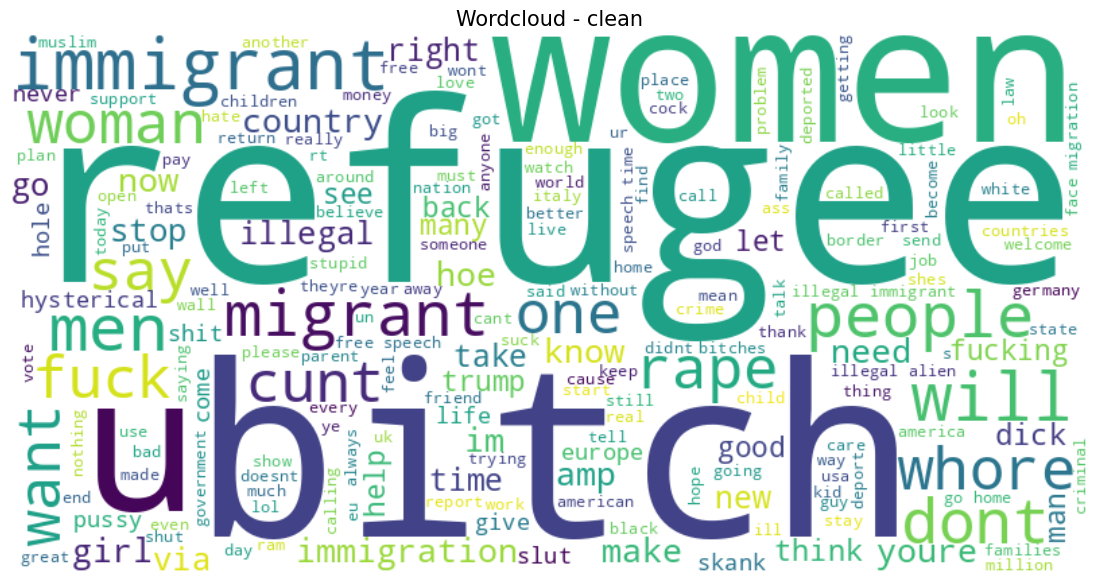

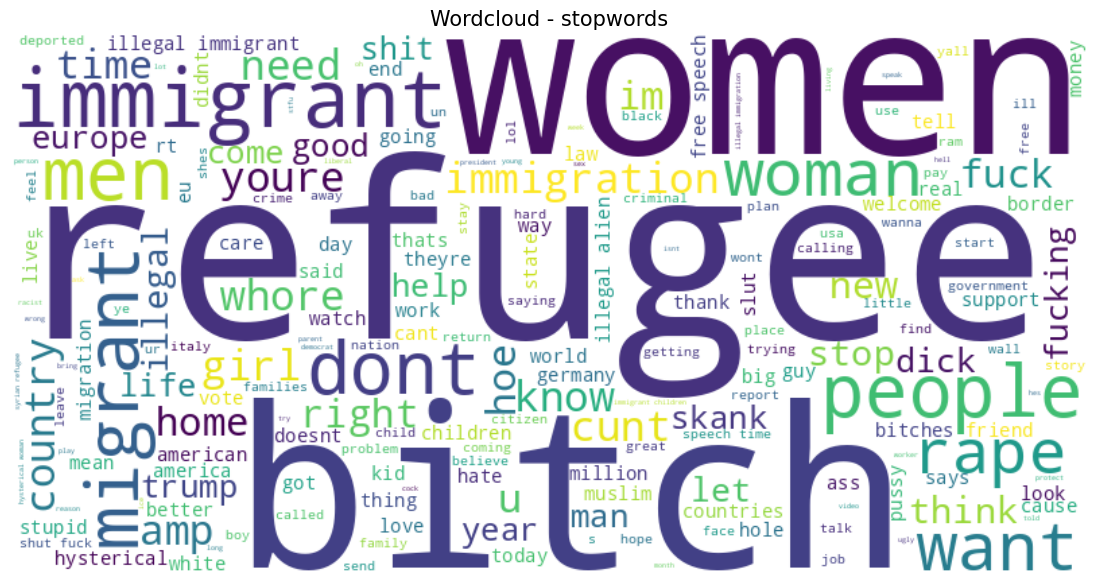

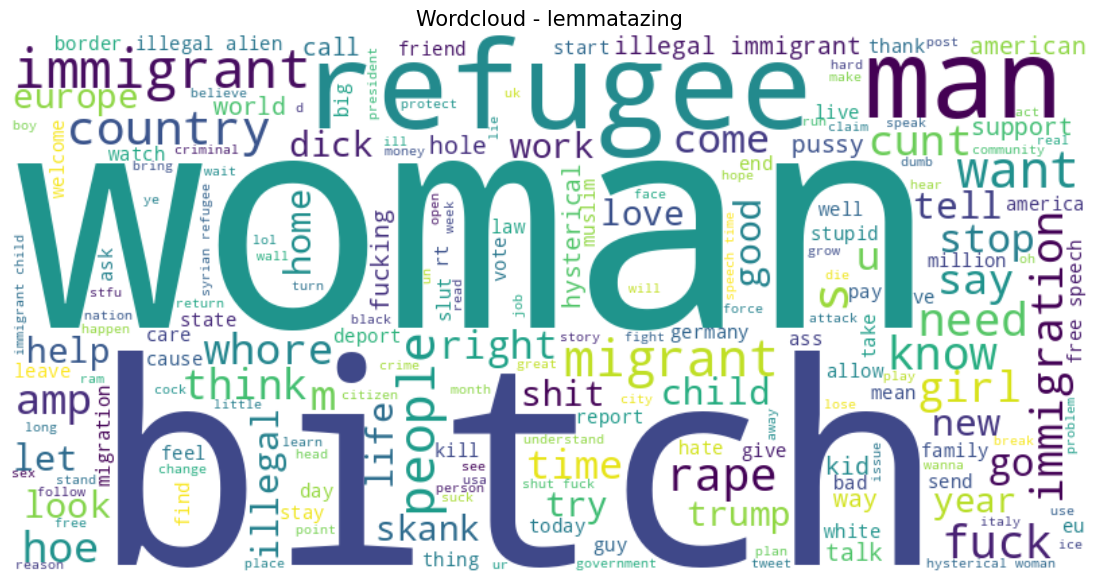

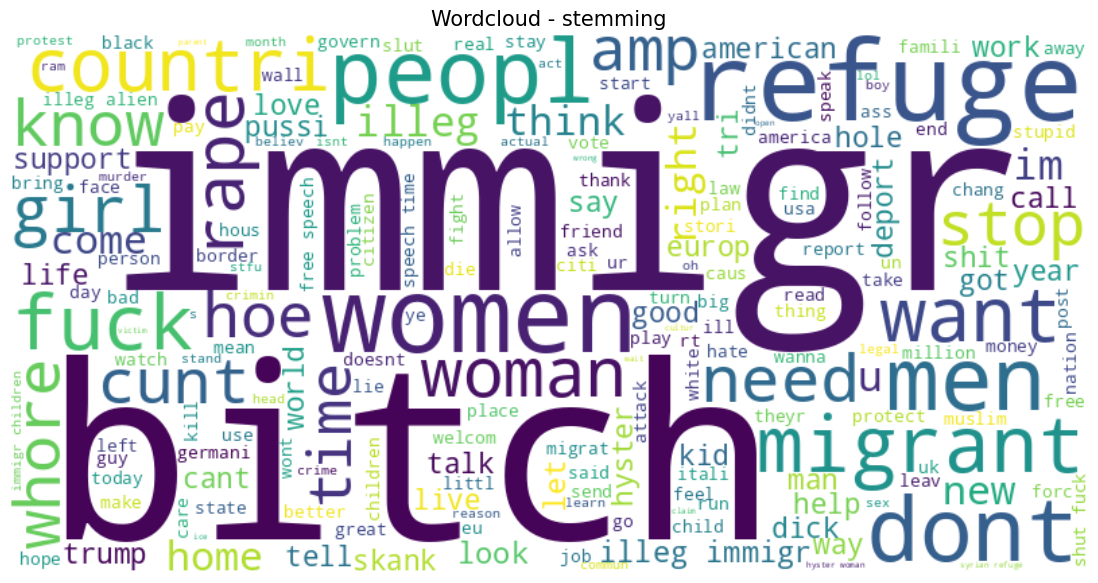


Vocabulary sizes for each tokenization procedure:
clean: 15687
stopwords: 15407
lemmatazing: 12532
stemming: 11349

Accuracy: 0.78
F1-score: 0.77

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1036
           1       0.80      0.63      0.70       764

    accuracy                           0.78      1800
   macro avg       0.78      0.76      0.76      1800
weighted avg       0.78      0.78      0.77      1800



In [ ]:
#test different tokenizations procedures


import pandas as pd
from datasets import load_dataset
import spacy, re
from nltk.stem import PorterStemmer
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from spacy.lang.en.stop_words import STOP_WORDS

dataset = load_dataset('cardiffnlp/tweet_eval', 'hate')
train_df = pd.DataFrame(dataset['train'])
texts_train = train_df['text'].tolist()


stemmer = PorterStemmer()
nlp = spacy.load('en_core_web_sm')

stopwords_en = STOP_WORDS

# cleaning (remove links, hashtags, mentions)
def re_clean(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower().strip()

# stopwords - use Spacy
def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stopwords_en])

# lemmatizing - use Spacy, despite it is slower then WordNetLemmatizer, however, the result is better: 12532(vocab size)
# also tried lemmatizing with WordNetLemmatizer here, it was faster, but the result was worse: 13890(vocab size)
def lemmatize_text(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc if token.text not in stopwords_en])

# stemming
def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

def tokenize(texts, procedure='clean'):
    tokenized = []
    for text in texts:
        text = re_clean(text)
        if procedure == 'stopwords':
            text = remove_stopwords(text)
        elif procedure == 'stemming':
            text = stem_text(remove_stopwords(text))
        elif procedure == 'lemmatazing':
            text = lemmatize_text(text)
        tokens = text.split()
        tokenized.append(tokens)
    return tokenized

# plotting
def plot_wordcloud(tokenized, title='Wordcloud'):
    all_tokens = [t for doc in tokenized for t in doc]
    text = ' '.join(all_tokens)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(15,7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=15)
    plt.show()

procedures = ['clean','stopwords','lemmatazing','stemming']
vocab_sizes = {}
for proc in procedures:
    tokenized = tokenize(texts_train, procedure=proc)
    plot_wordcloud(tokenized, title=f'Wordcloud - {proc}')
    vocab_size = len(set([t for doc in tokenized for t in doc]))
    vocab_sizes[proc] = vocab_size

print('\nVocabulary sizes for each tokenization procedure:')
for proc, size in vocab_sizes.items():
    print(f"{proc}: {size}")

#check the quality of the model

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

vectorizer = TfidfVectorizer(max_features=5000)
X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train,y_train,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter=500)
model.fit(X_train_split, y_train_split)
y_pred = model.predict(X_val_split)

accuracy = accuracy_score(y_val_split, y_pred)
f1 = f1_score(y_val_split, y_pred, average='weighted')
print(f"\nAccuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")
print('')
print(classification_report(y_val_split, y_pred))



In [ ]:

# used different vectorization techniques: Bag of words and TF-IDF with different options(+ different vocab sizes)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

train_texts = dataset['train']['text']
val_texts = dataset['validation']['text']
y_train = dataset['train']['label']
y_val = dataset['validation']['label']

procedures = ['clean','stopwords','lemmatazing','stemming']
vocab_sizes = [3000, 7000]  #for smaller and larger vocab

def tokens_to_texts(tokenized):
    return [' '.join(tokens) for tokens in tokenized]

results = {}

# evaluate all preprocessing + vectorizer + vocab combinations
for proc in procedures:
    tokenized_train = tokenize(train_texts, procedure=proc)
    tokenized_val = tokenize(val_texts, procedure=proc)

    texts_train_proc = tokens_to_texts(tokenized_train)
    texts_val_proc = tokens_to_texts(tokenized_val)

    results[proc] = {}

    for vocab in vocab_sizes:
        vectorizers = {
            f"BoW_{vocab}": CountVectorizer(max_features=vocab),
            f"TF-IDF_uni_{vocab}": TfidfVectorizer(max_features=vocab, ngram_range=(1, 1)),
            f"TF-IDF_uni+bi_{vocab}": TfidfVectorizer(max_features=vocab, ngram_range=(1, 2)),
            f"TF-IDF_sublinear_{vocab}": TfidfVectorizer(max_features=vocab, sublinear_tf=True),
        }

        for vec_name, vectorizer in vectorizers.items():
            X_train = vectorizer.fit_transform(texts_train_proc)
            X_val = vectorizer.transform(texts_val_proc)

            model = LogisticRegression(max_iter=500)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_val)
            acc = accuracy_score(y_val,y_pred)
            f1 = f1_score(y_val,y_pred,average='weighted')

            results[proc][vec_name] = {'accuracy': acc, 'f1': f1}

#summary grouped by preprocessing
print('\nSUMMARY\n')
for proc, vec_metrics in results.items():
    print(f"Preprocessing: {proc}")
    for vec_name, metrics in vec_metrics.items():
        parts = vec_name.split('_')
        vec_display = '_'.join(parts[:-1])
        vocab_display = parts[-1]
        print(f"{vec_display:<25s} vocab={vocab_display:<4s}  Acc={metrics['accuracy']:.2f}  F1={metrics['f1']:.2f}")
    print('')


SUMMARY

Preprocessing: clean
BoW                       vocab=3000  Acc=0.68  F1=0.67
TF-IDF_uni                vocab=3000  Acc=0.69  F1=0.69
TF-IDF_uni+bi             vocab=3000  Acc=0.71  F1=0.70
TF-IDF_sublinear          vocab=3000  Acc=0.69  F1=0.69
BoW                       vocab=7000  Acc=0.68  F1=0.68
TF-IDF_uni                vocab=7000  Acc=0.69  F1=0.69
TF-IDF_uni+bi             vocab=7000  Acc=0.70  F1=0.70
TF-IDF_sublinear          vocab=7000  Acc=0.70  F1=0.70

Preprocessing: stopwords
BoW                       vocab=3000  Acc=0.67  F1=0.66
TF-IDF_uni                vocab=3000  Acc=0.67  F1=0.67
TF-IDF_uni+bi             vocab=3000  Acc=0.70  F1=0.69
TF-IDF_sublinear          vocab=3000  Acc=0.68  F1=0.67
BoW                       vocab=7000  Acc=0.67  F1=0.67
TF-IDF_uni                vocab=7000  Acc=0.68  F1=0.67
TF-IDF_uni+bi             vocab=7000  Acc=0.68  F1=0.68
TF-IDF_sublinear          vocab=7000  Acc=0.68  F1=0.67

Preprocessing: lemmatazing
BoW                

Best data representation for both small and large vocab is **TF-IDF with both unigrams and bigrams** (vectorizer considers both single words and two-word sequences)

Also, in further application of Sklearn classification models I will used clean data (the best score for TF_IDF_uni+bi in small vocab: Acc=0.71, F1=0.70 and in large vocab: Acc=0.70, F1=0.70)

In [ ]:
#Sklearn classification models (Logistic Regression, LinearSVC, MultinomialNB)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report

#preprocessing
proc = 'clean'  #best preprocessing
tokenized_train = tokenize(dataset['train']['text'], procedure=proc)
tokenized_val = tokenize(dataset['validation']['text'], procedure=proc)
tokenized_test = tokenize(dataset['test']['text'], procedure=proc)

def tokens_to_texts(tokenized):
    return [' '.join(tokens) for tokens in tokenized]

texts_train = tokens_to_texts(tokenized_train)
texts_val = tokens_to_texts(tokenized_val)
texts_test = tokens_to_texts(tokenized_test)

y_train = dataset['train']['label']
y_val = dataset['validation']['label']
y_test = dataset['test']['label']

#TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
X_train = vectorizer.fit_transform(texts_train)
X_val = vectorizer.transform(texts_val)
X_test = vectorizer.transform(texts_test)

def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    return y_pred, acc, f1

models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'LinearSVC': LinearSVC(max_iter=5000, random_state=42),
    'MultinomialNB': MultinomialNB(alpha=1.0)
}
print('Baseline quality of the models with default settings(preprocessing: clean):\n')

results = {}

for name, model in models.items():
    y_val_pred, acc, f1 = evaluate_model(
        model, X_train, y_train, X_val, y_val
    )
    results[name] = {'accuracy': acc, 'f1': f1, 'y_pred': y_val_pred}

    print(f"{name}:")
    print(f"Validation Accuracy: {acc:.3f}")
    print(f"Validation F1-score: {f1:.3f}")
    print("-"*50)


Baseline quality of the models with default settings(preprocessing: clean):

Logistic Regression:
Validation Accuracy: 0.705
Validation F1-score: 0.702
--------------------------------------------------
LinearSVC:
Validation Accuracy: 0.684
Validation F1-score: 0.684
--------------------------------------------------
MultinomialNB:
Validation Accuracy: 0.689
Validation F1-score: 0.685
--------------------------------------------------


In [ ]:

#Sklearn classification models:hyperparameter tuning

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelBinarizer
import numpy as np


#preprocessing

proc = 'clean'  # best preprocessing
tokenized_train = tokenize(dataset['train']['text'], procedure=proc)
tokenized_val = tokenize(dataset['validation']['text'], procedure=proc)
tokenized_test = tokenize(dataset['test']['text'], procedure=proc)

def tokens_to_texts(tokenized):
    return [' '.join(tokens) for tokens in tokenized]

texts_train = tokens_to_texts(tokenized_train)
texts_val = tokens_to_texts(tokenized_val)
texts_test = tokens_to_texts(tokenized_test)

y_train = np.array(dataset['train']['label']).astype(int)
y_val = np.array(dataset['validation']['label']).astype(int)
y_test = np.array(dataset['test']['label']).astype(int)

#TF-IDF vectorization(unigrams and bigrams)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,3))
X_train = vectorizer.fit_transform(texts_train)
X_val = vectorizer.transform(texts_val)
X_test = vectorizer.transform(texts_test)


param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000,random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    },
    'LinearSVC': {
        'model': LinearSVC(max_iter=5000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'loss': ['squared_hinge'],
            'penalty': ['l2']
        }
    },
    'MultinomialNB': {
        'model': MultinomialNB(),
        'params': {'alpha': [0.1, 0.5, 1.0, 5.0]}
    }
}

#tune using GridSearchCV
best_models = {}

for name, model_info in param_grids.items():
    print(f"\nHyperparameter tuning for {name}:")

    model = model_info['model']
    params = model_info['params']

    grid = GridSearchCV(model, params, scoring='f1_macro',cv=3,n_jobs=-1,verbose=0)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    #for LinearSVC (CalibratedClassifierCV for ROC-AUC)
    if name == 'LinearSVC':
        calibrated_model = CalibratedClassifierCV(best_model, cv=3)
        calibrated_model.fit(X_train, y_train)
        best_model = calibrated_model

    y_val_pred = best_model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred, average='macro')

    best_models[name] = {
        'model': best_model,
        'accuracy': acc,
        'f1': f1,
        'best_params': grid.best_params_
    }

    print(f"Best params: {grid.best_params_}")
    print(f"Validation Accuracy: {acc:.3f}, F1-score: {f1:.3f}")
    print('-'*60)



Hyperparameter tuning for Logistic Regression:
Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Validation Accuracy: 0.700, F1-score: 0.688
------------------------------------------------------------

Hyperparameter tuning for LinearSVC:
Best params: {'C': 0.1, 'loss': 'squared_hinge', 'penalty': 'l2'}
Validation Accuracy: 0.695, F1-score: 0.685
------------------------------------------------------------

Hyperparameter tuning for MultinomialNB:
Best params: {'alpha': 0.5}
Validation Accuracy: 0.696, F1-score: 0.687
------------------------------------------------------------


In [ ]:

# Final testing

from sklearn.metrics import roc_auc_score

results = []

print('Final testing')
print('-'*80)

for name, info in best_models.items():
    model = info['model']

    y_pred = model.predict(X_test)

    #for ROC-AUC(handles multi-class)
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)
        else:
            #for LinearSVC
            y_proba = model.decision_function(X_test)

        if len(np.unique(y_test)) > 2:
            roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        else:
            roc_auc = roc_auc_score(y_test, y_proba[:, 1] if y_proba.ndim > 1 else y_proba)
    except Exception:
        roc_auc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")


# comparison

import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-Score',ascending=False).reset_index(drop=True)

print('\n')
print('Comparison of models')
print('-'*80)
print(results_df.to_string(index=True))

best_model_name = results_df.iloc[0]['Model']
best_f1 = results_df.iloc[0]['F1-Score']
print(f"\nBest model according to F1-Score: {best_model_name} (f1: {best_f1:.4f})")


Final testing
--------------------------------------------------------------------------------

Logistic Regression:
  Accuracy:  0.5788
  Precision: 0.6277
  Recall:    0.6116
  F1-Score:  0.5733
  ROC-AUC:   0.6967

LinearSVC:
  Accuracy:  0.5640
  Precision: 0.6219
  Recall:    0.6009
  F1-Score:  0.5551
  ROC-AUC:   0.6885

MultinomialNB:
  Accuracy:  0.5859
  Precision: 0.6311
  Recall:    0.6170
  F1-Score:  0.5815
  ROC-AUC:   0.7135


Comparison of models
--------------------------------------------------------------------------------
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0        MultinomialNB  0.585859   0.631144  0.617003  0.581532  0.713453
1  Logistic Regression  0.578788   0.627717  0.611649  0.573294  0.696749
2            LinearSVC  0.563973   0.621920  0.600902  0.555119  0.688453

Best model according to F1-Score: MultinomialNB (f1: 0.5815)


In [ ]:
#for the very best models, also, try to understand for which examples it is wrong:

import numpy as np
import pandas as pd

print('Error analysis for best model')
print('-'*60)

best_model_name = results_df.iloc[0]['Model']
best_model = best_models[best_model_name]['model']

y_pred = best_model.predict(X_test)
misclassified_idx = np.where(y_pred != y_test)[0]

print(f"\nTotal test examples: {len(y_test)}")
print(f"Misclassified examples: {len(misclassified_idx)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

errors_df = pd.DataFrame({
    'text': texts_test,
    'true_label': y_test,
    'pred_label': y_pred
})
errors_df = errors_df.loc[misclassified_idx]

#show 5 random errors
sample_errors = errors_df.sample(5, random_state=42)

for i, row in sample_errors.iterrows():
    print('\n' + '-'*40)
    print(f"True label:      {row['true_label']}")
    print(f"Predicted label: {row['pred_label']}")
    print('Text:')
    print(row['text'][:500])


Error analysis for best model
------------------------------------------------------------

Total test examples: 2970
Misclassified examples: 1230 (41.41%)

----------------------------------------
True label:      0
Predicted label: 1
Text:
niggas bitch about women because they not used to getting women

----------------------------------------
True label:      1
Predicted label: 0
Text:
sends more support to help agents get the outto report call

----------------------------------------
True label:      0
Predicted label: 1
Text:
bolton is a mainstream republican rhino chicken hawk that trump has to swallow i was really hoping he would make a huge difference in the middle east but it seems the powers that be wont cede that groundfor now we need him to hopefully me policy changes

----------------------------------------
True label:      0
Predicted label: 1
Text:
bitch im sad as hell shit ruined my whole day now i gotta go sit by a lake and skip rocks and contemplate life

----------

It is difficult for model to identify a non-hate, when a lot of words in the sentence are swear/curse/vulgar words. So, the sentence can not be hate (not toward particular person), but model still thinks it is hate due to the rude language.

# Regression



Using Colab cache for faster access to the 'semeval2018-tweetdataset' dataset.
/kaggle/input/semeval2018-tweetdataset

Basic info
Train set shape: (6908, 6)
Test set shape:  (3289, 6)
Dev set shape:   (893, 6)

Dataset summary
train sataset:
   features: ['Tweet', 'joy', 'sadness', 'anger', 'fear'],
   num_rows: 6908
 
test sataset:
   features: ['Tweet', 'joy', 'sadness', 'anger', 'fear'],
   num_rows: 3289
 
dev sataset:
   features: ['Tweet', 'joy', 'sadness', 'anger', 'fear'],
   num_rows: 893
 
 
Tweet length statistics:
count    6908.000000
mean       95.155327
std        36.581244
min         6.000000
25%        65.000000
50%       100.000000
75%       131.000000
max       160.000000
Name: tweet_length, dtype: float64


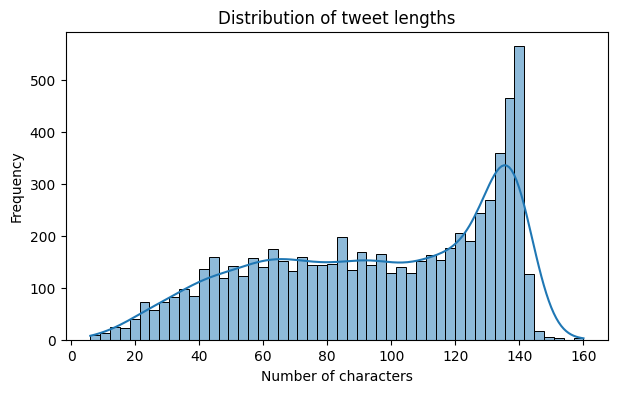


Random sample of tweets:

Tweet: Come and join in with #cakeclubhour tomorrow afternoon from 3pm! #bizhour #chirp
  joy: 0.479
  sadness: 0.0
  anger: 0.0
  fear: 0.0

Tweet: @PAKallman If you get it going with him, tag me the link please. I have a lot of friends who love following his unintentional hilarity.
  joy: 0.6709999999999999
  sadness: 0.0
  anger: 0.0
  fear: 0.0

Tweet: @AriZernial @NesquikMills don't let him discourage you Z! That's one of the best ideas yet!
  joy: 0.0
  sadness: 0.226
  anger: 0.0
  fear: 0.0


In [ ]:

# Regression, basic info about dataset

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load data and analyse it a little bit:
path = kagglehub.dataset_download('bmabir17/semeval2018-tweetdataset')
print(path)

files = {
    'train': os.path.join(path, 'tweet_data/train.csv'),
    'test': os.path.join(path, 'tweet_data/test.csv'),
    'dev': os.path.join(path, 'tweet_data/dev.csv')
}

train_df = pd.read_csv(files['train'], sep='\t', quoting=3, engine='python')
test_df = pd.read_csv(files['test'], sep='\t', quoting=3, engine='python')
dev_df = pd.read_csv(files['dev'], sep='\t', quoting=3, engine='python')

print('\nBasic info')
print(f"Train set shape: {train_df.shape}")
print(f"Test set shape:  {test_df.shape}")
print(f"Dev set shape:   {dev_df.shape}")

#text labels and cols
text_col_candidates = [c for c in train_df.columns if 'text' in c.lower() or 'tweet' in c.lower()]
if len(text_col_candidates) > 0:
    text_col = text_col_candidates[0]
else:
    raise ValueError('No text column found')

potential_targets = [c for c in train_df.columns if c not in [text_col, 'ID', 'id']]


#summary of datasets
def dataset_summary(df, text_col, label_cols):
    return {
        'features': [text_col] + label_cols,
        'num_rows': len(df)
    }

dataset_structure = {
    'train': dataset_summary(train_df, text_col, potential_targets),
    'test': dataset_summary(test_df, text_col, potential_targets),
    'dev': dataset_summary(dev_df, text_col, potential_targets)
}

print('\nDataset summary')
for split_name, info in dataset_structure.items():
    print(f"{split_name} sataset:")
    print(f"   features: {info['features']},")
    print(f"   num_rows: {info['num_rows']}")
    print(" ")
print(" ")

#tweet length
train_df['tweet_length'] = train_df[text_col].astype(str).apply(len)

print('Tweet length statistics:')
print(train_df['tweet_length'].describe())

plt.figure(figsize=(7,4))
sns.histplot(train_df['tweet_length'], bins=50, kde=True)
plt.title('Distribution of tweet lengths')
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.show()

print('\nRandom sample of tweets:')
for i in range(3):
    sample = train_df.sample(1).iloc[0]
    print(f"\nTweet: {sample[text_col]}")
    for col in potential_targets:
        print(f"  {col}: {sample[col]}")

For this regression task, I will predict **'fear' feature**

In [ ]:
# Regression models (Linear regression, Ridge regression, Random Forest)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import pandas as pd
import numpy as np

target_col = 'fear'

X_train, y_train = train_df[text_col], train_df[target_col]
X_dev, y_dev = dev_df[text_col], dev_df[target_col]
X_test, y_test = test_df[text_col], test_df[target_col]

#TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

#take small sample for tuning, because otherwise random forest loads for too long
sample_idx = np.random.choice(range(X_train_vec.shape[0]), size=5000, replace=False)
X_small = X_train_vec[sample_idx]
y_small = np.array(y_train)[sample_idx]

#tuning hyperparameters func(used GridSearchCV for small grids and RandomizedSearchCV for larger grids)
def tune_model(model, param_grid=None):
    if param_grid:
        total_combinations = np.prod([len(v) for v in param_grid.values()])
        if total_combinations <= 10:
            search = GridSearchCV(model, param_grid=param_grid, scoring='r2', cv=2, n_jobs=-1)
        else:
            search = RandomizedSearchCV(model, param_distributions=param_grid,
                                        n_iter=10, scoring='r2', cv=2, n_jobs=-1, random_state=42)
        search.fit(X_small, y_small)
        return search.best_estimator_, search.best_params_
    else:
        model.fit(X_small, y_small)
        return model, None
#to predict R squared and RMSE
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return y_pred, r2, rmse

models = [
    {'name': 'Linear Regression', 'model': LinearRegression(), 'param_grid': None},
    {'name': 'Ridge Regression', 'model': Ridge(), 'param_grid': {'alpha': [0.1, 1, 10]}},
    {'name': 'Random Forest', 'model': RandomForestRegressor(random_state=42),
     'param_grid': {'n_estimators': [50, 100], 'max_depth': [10, 20]}}
]

#baseline for each model (before tuning)
print('\nBaseline (no tuning)')
baseline_results = []
for m in models:
    model, _ = tune_model(m['model'],param_grid=None)
    model.fit(X_train_vec, y_train)
    _, r2, rmse = evaluate_model(model, X_test_vec, y_test)
    baseline_results.append({'Model': m['name'], 'R²': r2, 'RMSE': rmse})
    print(f"{m['name']} → R²: {r2:.4f} | RMSE: {rmse:.4f}")

#models after tuning
print('\nAfter hyperparameter tuning')
tuned_results = []
for m in models:
    best_model, best_params = tune_model(m['model'], m['param_grid'])
    best_model.fit(X_train_vec, y_train)
    _, r2, rmse = evaluate_model(best_model, X_test_vec, y_test)
    tuned_results.append({'Model': m['name'], 'R²': r2, 'RMSE': rmse, 'Best Params': best_params})
    print(f"{m['name']} → R²: {r2:.4f} | RMSE: {rmse:.4f} | Best params: {best_params}")

#compare
results_df = pd.DataFrame(tuned_results)
baseline_df = pd.DataFrame(baseline_results)
combined_df = pd.concat([baseline_df, results_df], ignore_index=True)

print('\nModel comparison')
print(combined_df)

#best model based on R squared
best_model_name = combined_df.loc[combined_df['R²'].idxmax(),'Model']
best_r2 = combined_df['R²'].max()
print(f"\nBest model based on R²: {best_model_name} (R² = {best_r2:.4f})")


Baseline (no tuning)
Linear Regression → R²: 0.2996 | RMSE: 0.2127
Ridge Regression → R²: 0.3291 | RMSE: 0.2081
Random Forest → R²: 0.2921 | RMSE: 0.2138

After hyperparameter tuning
Linear Regression → R²: 0.2996 | RMSE: 0.2127 | Best params: None
Ridge Regression → R²: 0.3291 | RMSE: 0.2081 | Best params: {'alpha': 1}
Random Forest → R²: 0.2801 | RMSE: 0.2156 | Best params: {'max_depth': 20, 'n_estimators': 100}

Model comparison
               Model        R²      RMSE  \
0  Linear Regression  0.299614  0.212655   
1   Ridge Regression  0.329061  0.208136   
2      Random Forest  0.292052  0.213800   
3  Linear Regression  0.299614  0.212655   
4   Ridge Regression  0.329061  0.208136   
5      Random Forest  0.280142  0.215591   

                              Best Params  
0                                     NaN  
1                                     NaN  
2                                     NaN  
3                                    None  
4                            {'alp

Linear regression and ridge regression showed a little bit better results than random forest. The best model is ridge regression (the best result), due to regularization.